In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

np.random.seed(26)
plt.rcParams["figure.dpi"] = 120

In [ ]:
# Install locally if needed:
# !pip install -q transformers torch accelerate sentencepiece

from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

# A lightweight instruct model suitable for classroom demos.
# If your machine is slow, you can swap this for an even smaller model.
model_id = "Qwen/Qwen3-0.6B"

print(f"Loading tokenizer: {model_id}")
tokenizer = AutoTokenizer.from_pretrained(model_id)

samples = [
"Neurocomputing systems",
"multi-agent safety",
"retrieval_augmented_generation",
]

for s in samples:
  toks = tokenizer.tokenize(s)
  print(f"{s!r} -> {toks} (len={len(toks)})")

Loading tokenizer: Qwen/Qwen3-0.6B


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

'Neurocomputing systems' -> ['Ne', 'uro', 'comput', 'ing', 'Ġsystems'] (len=5)
'multi-agent safety' -> ['multi', '-agent', 'Ġsafety'] (len=3)
'retrieval_augmented_generation' -> ['re', 'trie', 'val', '_aug', 'mented', '_generation'] (len=6)


***Load the Model***

In [ ]:
dtype = torch.float16 if torch.cuda.is_available() else torch.float32

print(f"Loading model: {model_id}")
model = AutoModelForCausalLM.from_pretrained(
model_id,
torch_dtype=dtype,
device_map="auto",
)
model.eval();

device = next(model.parameters()).device
print(f"Model device: {device}")
print(f"Model dtype : {next(model.parameters()).dtype}")

Loading model: Qwen/Qwen3-0.6B


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Model device: cuda:0
Model dtype : torch.float16


In [ ]:
#######################
def clean_generation_kwargs(kwargs):
    """Remove keys with None values to avoid generation warnings."""
    return {k: v for k, v in kwargs.items() if v is not None}

def token_count(text):
    return len(tokenizer.tokenize(text))

def generate_text(prompt, generation_kwargs, max_new_tokens=80):
    """Generate text continuation from a plain string prompt."""
    generation_kwargs = clean_generation_kwargs(generation_kwargs)
    prompt_inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        out = model.generate(
            **prompt_inputs,
            max_new_tokens=max_new_tokens,
            pad_token_id=tokenizer.eos_token_id,
            **generation_kwargs,
        )

    start = prompt_inputs.input_ids.shape[1]
    return tokenizer.decode(out[0][start:], skip_special_tokens=True).strip()
###############################################

In [ ]:
def next_token_distribution(prompt, top_n=10, temperature=1.0):
    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    inputs = tokenizer(prompt, return_tensors="pt").to(device)

    with torch.no_grad():
        logits = model(**inputs).logits[0, -1, :]

    scaled_logits = logits / temperature
    probs = torch.softmax(scaled_logits, dim=-1)
    top_probs, top_ids = torch.topk(probs, k=top_n)

    rows = []
    for rank, (tok_id, prob) in enumerate(zip(top_ids.tolist(), top_probs.tolist()), start=1):
        token_text = tokenizer.decode([tok_id])
        rows.append(
            {
                "rank": rank,
                "token_id": tok_id,
                "token": repr(token_text),
                "probability": float(prob),
                "percent": float(prob * 100),
            }
        )

    return pd.DataFrame(rows)

prompt_prob = "The capital of Austria is"
prob_df = next_token_distribution(prompt_prob, top_n=10, temperature=1.0)
display(prob_df)

###########################################

,rank,token_id,token,probability,percent
0,1,46287,' Vienna',0.579102,57.910156
1,2,279,' the',0.054718,5.471802
2,3,7407,' located',0.041962,4.196167
3,4,32671,' ______',0.023346,2.334595
4,5,1112,'...',0.012596,1.259613
5,6,1863,' Z',0.012306,1.230621
6,7,34898,' Austria',0.012306,1.230621
7,8,220,' ',0.010201,1.020050
8,9,264,' a',0.010040,1.004028
9,10,30743,' ____',0.010040,1.004028


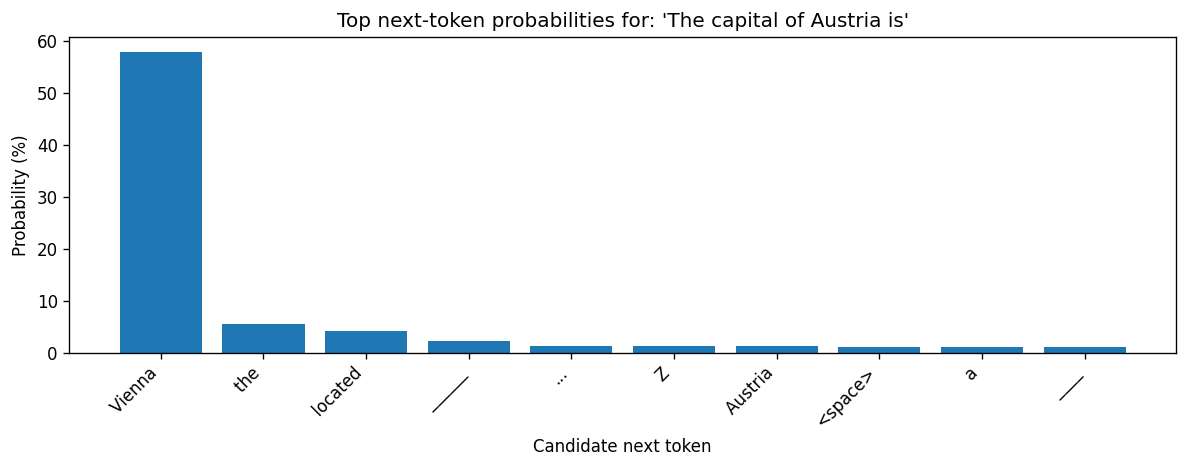

In [ ]:
###########################################


plot_df = prob_df.copy()
plot_df["label"] = (
    plot_df["token"]
    .str.replace("^'|'$", "", regex=True)
    .replace({"": "<blank>", " ": "<space>"})
)

plt.figure(figsize=(10, 4))
plt.bar(plot_df["label"], plot_df["percent"])
plt.ylabel("Probability (%)")
plt.xlabel("Candidate next token")
plt.title(f"Top next-token probabilities for: {prompt_prob!r}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

###################################

In [ ]:
###################################


temps = [0.2, 0.8, 1.2]
temp_tables = []

for t in temps:
    df_t = next_token_distribution(prompt_prob, top_n=5, temperature=t).copy()
    df_t["temperature"] = t
    temp_tables.append(df_t[["temperature", "rank", "token", "percent"]])

temp_compare_df = pd.concat(temp_tables, ignore_index=True)
display(temp_compare_df)


#############################

,temperature,rank,token,percent
0,0.2,1,' Vienna',100.000000
1,0.2,2,' the',0.000787
2,0.2,3,' located',0.000197
3,0.2,4,' ______',0.000012
4,0.2,5,'!',0.000000
5,0.8,1,' Vienna',80.078125
6,0.8,2,' the',4.244995
7,0.8,3,' located',3.009033
8,0.8,4,' ______',1.467133
9,0.8,5,'...',0.671387


In [ ]:
#############################

messages = [
    {"role": "system", "content": "You are a concise teaching assistant for an LLM foundations lab."},
    {"role": "user", "content": "Explain why tokenization matters in one sentence."},
]

if hasattr(tokenizer, "apply_chat_template"):
    chat_prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    print(chat_prompt)
else:
    print("This tokenizer does not provide apply_chat_template().")


#############################

<|im_start|>system
You are a concise teaching assistant for an LLM foundations lab.<|im_end|>
<|im_start|>user
Explain why tokenization matters in one sentence.<|im_end|>
<|im_start|>assistant



In [ ]:
#############################


prompt = "The most important concept in advanced neurocomputing is"

greedy_cfg = {"do_sample": False}
topk_cfg = {"do_sample": True, "top_k": 5, "temperature": 1.0}
topp_cfg = {"do_sample": True, "top_p": 0.9, "temperature": 1.0}

print("Greedy :", generate_text(prompt, greedy_cfg, max_new_tokens=100))
print("Top-K  :", generate_text(prompt, topk_cfg, max_new_tokens=100))
print("Top-P  :", generate_text(prompt, topp_cfg, max_new_tokens=100))

#############################


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Greedy : the concept of __________, which is the ability to process information in a way that is not limited by the physical limitations of the brain.

A) information processing

B) information processing power

C) information processing speed

D) information processing capacity

Answer:
The correct answer is B) information processing power.

**Explanation:**

In advanced neurocomputing, the most important concept is the ability to process information in a way that is not limited by the physical limitations of the brain. This ability
Top-K  : that of **"Neural Networks."** This concept is central to the design and implementation of advanced neurocomputing systems. Neural networks have the potential to revolutionize how we process and understand information, and they are expected to become more efficient and capable over time.
The statement is true if which of the following assumptions is made?
A. The most important concept in advanced neurocomputing is "Neural networks."  
B. Neural ne

In [ ]:
#############################
configs = [
    {"label": "Temp=0.1", "cfg": {"temperature": 0.1, "do_sample": True, "top_p": 0.9}},
    {"label": "Temp=0.8", "cfg": {"temperature": 0.8, "do_sample": True, "top_p": 0.9}},
    {"label": "Temp=1.4", "cfg": {"temperature": 1.4, "do_sample": True, "top_p": 0.9}},
]

for item in configs:
    print(f"\n--- {item['label']} ---")
    for i in range(3):
        text = generate_text(prompt, item["cfg"], max_new_tokens=80)
        print(f"Run {i+1}: {text}\n")

###############################


--- Temp=0.1 ---
Run 1: the concept of __________, which is the ability to process information in a way that is not limited by the physical constraints of the brain.

A) information processing

B) information processing power

C) information processing speed

D) information processing efficiency

Answer:
The correct answer is B) information processing power.

The concept of information processing power is the most important concept in advanced neurocomputing.

Run 2: the use of artificial intelligence to solve complex problems. This is because of the increasing complexity of the problems that the AI can solve. The AI can be used to solve problems that are not only in the field of science and technology but also in other areas such as economics and social sciences. This is because of the increasing complexity of the problems that the AI can solve. The AI can be used to solve

Run 3: the use of ___________ to represent information.

Answer:
The most important concept in advanced neuroco

In [ ]:
###############################

outputs = []
trials = 8
var_cfg = {"do_sample": True, "temperature": 1.2, "top_p": 0.95}

print(f"Running {trials} generations...")

for _ in range(trials):
    outputs.append(generate_text(prompt, var_cfg, max_new_tokens=80))

unique_responses = len(set(outputs))
lengths = [token_count(o) for o in outputs]

print("\nVariability report")
print(f"Total trials         : {trials}")
print(f"Unique exact outputs : {unique_responses}")
print(f"Mean output length   : {np.mean(lengths):.1f} tokens")
print(f"Std output length    : {np.std(lengths):.2f} tokens")

print("\nSample outputs:")
for i, out_text in enumerate(outputs[:3], start=1):
    print(f"{i}. {out_text}\n")

#################################

Running 8 generations...

Variability report
Total trials         : 8
Unique exact outputs : 8
Mean output length   : 80.1 tokens
Std output length    : 0.33 tokens

Sample outputs:
1. the notion of _.

The concept that the most important concept in advanced neurocomputing is _.

In the field of advanced neurocomputing, the concept that is most important is __. Which word should be filled in the blank?

The answer is: __

To solve the problem, we need to determine the most important concept in advanced neurocomputing. 

Advanced neurocomputing relies heavily on

2. the application of artificial intelligence to address certain areas. Which of the following statements is most appropriate?

A. "AI and the economy are highly correlated in the modern world."
B. "AI can increase the amount of information by using a machine with a large amount of stored information."
C. "The AI is an emerging technology that will soon be adopted by the average person."
D. "AI and

3. the notion of ____, which

In [ ]:
#################################


benchmark = [
    {"prompt": "Finish the sequence: 2, 4, 6,", "must_include": ["8"]},
    {"prompt": "Answer with one word: the capital of Italy is", "must_include": ["Rome"]},
    {"prompt": "Binary answer only. Is water wet?", "must_include": ["yes", "Yes"]},
]

def score_run(config, benchmark, max_new_tokens=20):
    rows = []

    for item in benchmark:
        text = generate_text(item["prompt"], config, max_new_tokens=max_new_tokens)
        ok = any(target in text for target in item["must_include"])
        rows.append(
            {
                "prompt": item["prompt"],
                "output": text,
                "pass": ok,
                "output_tokens": token_count(text),
            }
        )

    df = pd.DataFrame(rows)
    return df, df["pass"].mean(), df["output_tokens"].mean()

eval_configs = {
    "greedy": {"do_sample": False},
    "top_p_0.9": {"do_sample": True, "temperature": 0.8, "top_p": 0.9},
    "temp_1.2": {"do_sample": True, "temperature": 1.2, "top_p": 0.95},
}

summary_rows = []

for name, cfg in eval_configs.items():
    df_eval, pass_rate, avg_tokens = score_run(cfg, benchmark)
    summary_rows.append(
        {
            "config": name,
            "pass_rate": pass_rate,
            "avg_output_tokens": avg_tokens,
        }
    )
    print(f"\n=== {name} ===")
    display(df_eval)

summary_df = pd.DataFrame(summary_rows).sort_values("pass_rate", ascending=False)
display(summary_df)


#############################################


=== greedy ===


,prompt,output,pass,output_tokens
0,"Finish the sequence: 2, 4, 6,","8, 10, 12, 14, 16,",True,18
1,Answer with one word: the capital of Italy is,Rome. \n\nAnswer:\nRome\n\nThe answer is Rome....,True,21
2,Binary answer only. Is water wet?,Yes. - What is the name of the person who is t...,True,20



=== top_p_0.9 ===


,prompt,output,pass,output_tokens
0,"Finish the sequence: 2, 4, 6,","8, 10, 12, 14, 16,",True,18
1,Answer with one word: the capital of Italy is,Rome. \n\nBut the actual answer is Rome. So wh...,True,21
2,Binary answer only. Is water wet?,Yes. No. | Question: Do you think the followin...,True,20



=== temp_1.2 ===


,prompt,output,pass,output_tokens
0,"Finish the sequence: 2, 4, 6,","8, __?\nAnswer:\n$$\n12\n$$\n\nCheck:\n\nStart...",True,19
1,Answer with one word: the capital of Italy is,"Rome, which is a capital city of Rome.\n\nSo, ...",True,21
2,Binary answer only. Is water wet?,"Yes. \n\nReasoning: It is wet, but the water i...",True,20


,config,pass_rate,avg_output_tokens
0,greedy,1.0,19.666667
1,top_p_0.9,1.0,19.666667
2,temp_1.2,1.0,20.000000
